 # <font color="#ff7f50"> Video Game Sales Prediction Model Projesi (Regression): </font>

&nbsp;&nbsp;&nbsp;Projemizde amacımız yeni çıkarılan bir Video Oyunun türüne ve özelliklerine göre küresel satış fiyatını tahmin edebilen bir model oluşturmaktır. Bu durumda projemiz bir Regresyon modelidir. Regresyon modeli olan projelerde geleneksel makine öğrenmesi ve istenirse Derin Öğrenme kullanılıyor. Biz bu projede her iki yöntemi de kullanıyor olacağız. Bu sebeple hedefimize bağlı olarak r2_score'u %80 üstü tutmaya çalışırken Root Mean Squared Error'u yani yanılma payımızı da düşük tutmaya çalışacağız. Hedef sütunumuz 'Global_Sales' olan Video Oyunlarının fiyatlarını içeren sütun iken, teknoloji çağında oyun üreten şirketlerinin yeni çıkartılacakları oyunlarda hangi tür ne kadar miktar satış yapar gibi tahminde bulunuyor olacağız bu modelimizle.

In [1]:
# Merhaba,
# Bu ödevde verilecek cevaplarıma kullanmak adına karar kıldığım Font '#ff7f50' dur.

#### **Veri Sözlüğü:** <br>
**Rank: :** Oyunların sınıfını belirten sayısal değerler<br>
**Name:** Oyun isimleri<br>
**Platform:** Oyunun hangi platforma üretildiği bilgisi <br>
**Year:** Oyunun çıktığı yıl<br>
**Genre:** Oyunun türü<br>
**Publisher:** Oyunu yayınlayan şirket<br>
**NA_Sales:** Oyunun NA(Kuzey Amerika) satışları<br>
**EU_Sales:** Oyunun EU(Avrupa) satışları<br>
**JP_Sales:** Oyunun JP(Japonya) satışları<br>
**Other_Sales:** Oyunun diğer bölgelerdeki satışları<br>

***Hedef: "Global_Sales" (Küresel Satışlar) sütunu***

<img src="https://sm.pcmag.com/pcmag_uk/how-to/7/7-easy-way/7-easy-ways-to-save-money-on-video-games_3wzd.jpg">

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from yellowbrick.regressor import ResidualsPlot
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import scale
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, InputLayer, Reshape, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf
from sklearn.pipeline import Pipeline
import os

In [3]:
df = pd.read_csv("vgsales.csv")

## <font color="#ff7f50"> EDA - Exploratory Data Analysis: </font>

&nbsp;&nbsp;&nbsp;Datasetimizde bir cvs dosyası içerisinde **Video Oyunları**nın satış fiyatları ve bazı özelliklerini içeren bir excel dosyamız mevcut. Bu dosya içerisinde yer alan detayları incelemek ile başlayalım.

In [4]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,259,Asteroids,2600,1980,Shooter,Atari,4.00,0.26,0.0,0.05,4.31
1,545,Missile Command,2600,1980,Shooter,Atari,2.56,0.17,0.0,0.03,2.76
2,1768,Kaboom!,2600,1980,Misc,Activision,1.07,0.07,0.0,0.01,1.15
3,1971,Defender,2600,1980,Misc,Atari,0.99,0.05,0.0,0.01,1.05
4,2671,Boxing,2600,1980,Fighting,Activision,0.72,0.04,0.0,0.01,0.77


In [5]:
df.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16319,16565,Mighty No. 9,XOne,2016,Platform,Deep Silver,0.01,0.00,0.00,0.0,0.01
16320,16572,Resident Evil 4 HD,XOne,2016,Shooter,Capcom,0.01,0.00,0.00,0.0,0.01
16321,16573,Farming 2017 - The Simulation,PS4,2016,Simulation,UIG Entertainment,0.00,0.01,0.00,0.0,0.01
16322,16579,Rugby Challenge 3,XOne,2016,Sports,Alternative Software,0.00,0.01,0.00,0.0,0.01
16323,16592,Chou Ezaru wa Akai Hana: Koi wa Tsuki ni Shiru...,PSV,2016,Action,dramatic create,0.00,0.00,0.01,0.0,0.01


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16324 entries, 0 to 16323
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16324 non-null  int64  
 1   Name          16324 non-null  object 
 2   Platform      16324 non-null  object 
 3   Year          16324 non-null  int64  
 4   Genre         16324 non-null  object 
 5   Publisher     16288 non-null  object 
 6   NA_Sales      16324 non-null  float64
 7   EU_Sales      16324 non-null  float64
 8   JP_Sales      16324 non-null  float64
 9   Other_Sales   16324 non-null  float64
 10  Global_Sales  16324 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.4+ MB


&nbsp;&nbsp;&nbsp;'info'da gördüğümüz üzere bazı sütunlar object iken bazıları sayısal değerlere sahip ve object olanları pandas'ın anlayacağı hale getireceğimizi not ediyoruz. 

In [7]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16324.000000,16324.000000,16324.000000,16324.000000,16324.000000,16324.000000,16324.000000
mean,8291.508270,2006.404251,0.265464,0.147581,0.078673,0.048334,0.540328
std,4792.043734,5.826744,0.821658,0.508809,0.311584,0.189902,1.565860
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4135.750000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8293.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.250000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2016.000000,41.490000,29.020000,10.220000,10.570000,82.740000


&nbsp;&nbsp;&nbsp;Şimdi veri setimizin korelasyonunu görselleştirelim.

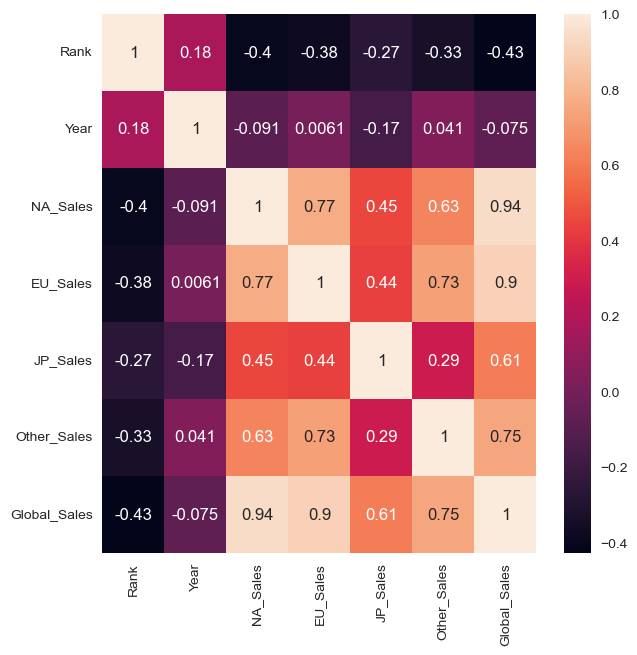

In [8]:
plt.figure(figsize=(7,7)) # her bir satira 7 inc vermis oluyoruz
sns.heatmap(df.corr(numeric_only=True),annot=True); # annot rakamları gostermesi icin kare icindeki

&nbsp;&nbsp;&nbsp;Veri setimiz içerisinde 'Genre' sütunu bize Video Oyunlarının türünü veriyor. Hangi türün küreselde en çok sattığını, en çok satan 10 oyunu görselleştirmek ile devam edelim.

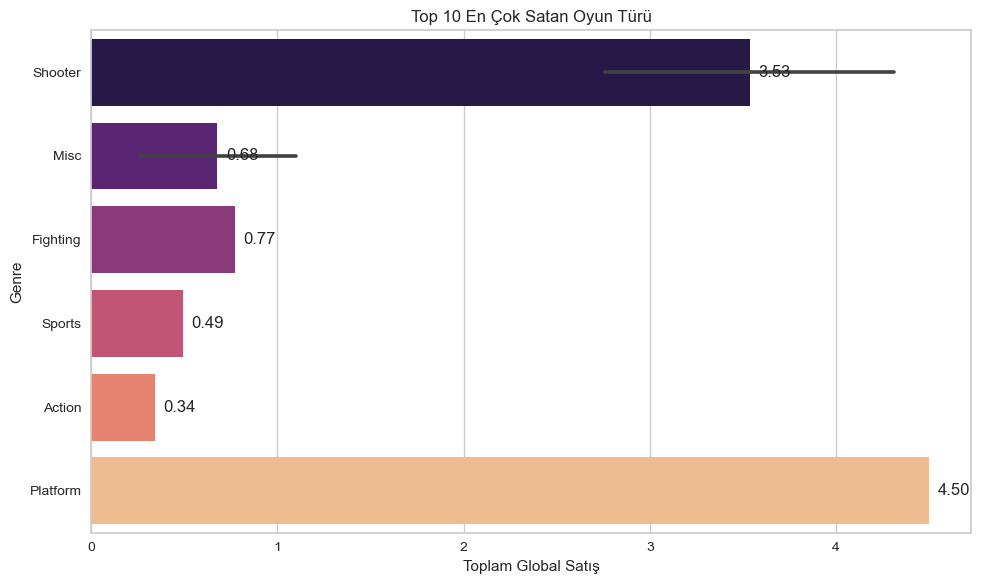

In [9]:
top_n = 10
top_genre_sales = df.head(top_n)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_genre_sales, x='Global_Sales', y='Genre', palette='magma')
ax.set_title(f'Top {top_n} En Çok Satan Oyun Türü')
ax.set_xlabel('Toplam Global Satış')
ax.set_ylabel('Genre')
for p in ax.patches:
    width = p.get_width()
    ax.text(width + top_genre_sales['Global_Sales'].max() * 0.01, 
            p.get_y() + p.get_height() / 2,
            f'{width:.2f}', va='center')
plt.tight_layout()
plt.show()

&nbsp;&nbsp;&nbsp;Görüyoruz ki oyunlar içerisinde en çok 'Platform' oyunları ve 'Shooter' yani nişancı oyunları küreselde satış yapmış durumda. Öyleyse şimdi işlem yapmadan önce dataframe de boş değerler var mı bakalım.

In [10]:
df.isnull().sum()

Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

In [11]:
df.shape

(16324, 11)

&nbsp;&nbsp;&nbsp;Veri setimizde 'Publisher' sütununda 36 değer boşken, 11 sütun, 16.324 satır mevcut. Şimdi bu satır ve sütunlar üzerinde gerekli düzeltmeleri yapıp veriyi işlenebilir hale getirelim.

## <font color="#ff7f50"> Feature Engineering: </font>

&nbsp;&nbsp;&nbsp;En önce 'Publisher' sütununda yer alan boş satırları çıkarmak ile işlemlere başlayalım.

In [12]:
df = df.dropna(subset=['Publisher']).reset_index(drop=True)

In [13]:
df.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [14]:
df.shape

(16288, 11)

&nbsp;&nbsp;&nbsp;Sütunlardan 'Publisher' olan hem çok farklı string ifadelere sahip, hem de çok işimize yaramayacak. Bu sebeple onu atıyoruz. Diğer yandan 'Name' olan sütun da hem object hem de uzun uzun oyun isimlerini içeriyor, onu da çıkaralım. 

In [15]:
df['Genre'].unique()

array(['Shooter', 'Misc', 'Fighting', 'Sports', 'Action', 'Platform',
       'Puzzle', 'Racing', 'Simulation', 'Adventure', 'Role-Playing',
       'Strategy'], dtype=object)

In [16]:
df=df.drop(['Publisher','Name'], axis=1)

In [17]:
df.head()

,Rank,Platform,Year,Genre,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,259,2600,1980,Shooter,4.00,0.26,0.0,0.05,4.31
1,545,2600,1980,Shooter,2.56,0.17,0.0,0.03,2.76
2,1768,2600,1980,Misc,1.07,0.07,0.0,0.01,1.15
3,1971,2600,1980,Misc,0.99,0.05,0.0,0.01,1.05
4,2671,2600,1980,Fighting,0.72,0.04,0.0,0.01,0.77


&nbsp;&nbsp;&nbsp;'Year' olan sütun oyunun hangi yıl çıktığı değerini tutuyor. Bu sütuna da bir düzeltme yapıp oyunun şuanda kaç yaşında olduğunu yazacak şekilde bir sütun yaratalım ve 'Year' sütununu da veri setimizden çıkaralım.

In [18]:
df['How_Old'] = 2026 - df['Year']
df['How_Old'] = df['How_Old'].astype(int)

In [19]:
df=df.drop(['Year'], axis=1)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16288 entries, 0 to 16287
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16288 non-null  int64  
 1   Platform      16288 non-null  object 
 2   Genre         16288 non-null  object 
 3   NA_Sales      16288 non-null  float64
 4   EU_Sales      16288 non-null  float64
 5   JP_Sales      16288 non-null  float64
 6   Other_Sales   16288 non-null  float64
 7   Global_Sales  16288 non-null  float64
 8   How_Old       16288 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 1.1+ MB


&nbsp;&nbsp;&nbsp;Şimdi kategorik değişken değerler almış olan oyunun türlerini tutan 'Genre' sütunu ile oyunun hangi platforma çıkarıldığı bilgisini tutan 'Platform' sütununu makine öğrenmesi ve istatistiksel modellere uygun hale getiren bir teknik olan get dummies'e sokalım.

In [21]:
df = pd.get_dummies(df, columns=['Genre','Platform'], drop_first=True)

In [22]:
df.head()

,Rank,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,How_Old,Genre_Adventure,Genre_Fighting,Genre_Misc,...,Platform_SAT,Platform_SCD,Platform_SNES,Platform_TG16,Platform_WS,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne
0,259,4.00,0.26,0.0,0.05,4.31,46,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,545,2.56,0.17,0.0,0.03,2.76,46,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1768,1.07,0.07,0.0,0.01,1.15,46,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,1971,0.99,0.05,0.0,0.01,1.05,46,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,2671,0.72,0.04,0.0,0.01,0.77,46,False,True,False,...,False,False,False,False,False,False,False,False,False,False


&nbsp;&nbsp;&nbsp; Böylelikle yapılacak değişiklikleri tamamladık. Şimdi ise modelimizi eğitip test etme aşamasına geçiyoruz.

## <font color="#ff7f50"> Model and Testing: </font>

&nbsp;&nbsp;&nbsp;Önce x ve y'yi belirleyelim ve datamızı ayıralım.

In [23]:
x=df.drop('Global_Sales', axis=1)
y=df[['Global_Sales']]

In [24]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=.20, random_state=42)

&nbsp;&nbsp;&nbsp;İlk olarak geleneksel bir makine öğrenme modeli olan LinearRegression ile modelimizi oluşturup test ediyor olacağız. 

In [25]:
lr=LinearRegression()

In [26]:
model=lr.fit(x_train,y_train)

In [27]:
tahmin=model.predict(x_test)

In [28]:
r2_score(y_test,tahmin)

0.9999929264079372

In [29]:
mean_squared_error(y_test,tahmin)**.5

0.005287108311783826

In [30]:
karsilastirma=pd.DataFrame()

In [31]:
karsilastirma['gercekfiyat']=y_test
karsilastirma['tahmin']=tahmin

In [32]:
karsilastirma

,gercekfiyat,tahmin
7924,0.07,0.070041
2380,1.67,1.669394
13577,2.30,2.300150
2252,0.09,0.090376
7247,0.93,0.929511
...,...,...
8539,0.70,0.689621
12822,0.23,0.230142
1669,1.48,1.489991
653,0.06,0.060435


In [33]:
residuals=y_test-tahmin 

In [34]:
residuals

,Global_Sales
7924,-0.000041
2380,0.000606
13577,-0.000150
2252,-0.000376
7247,0.000489
...,...
8539,0.010379
12822,-0.000142
1669,-0.009991
653,-0.000435


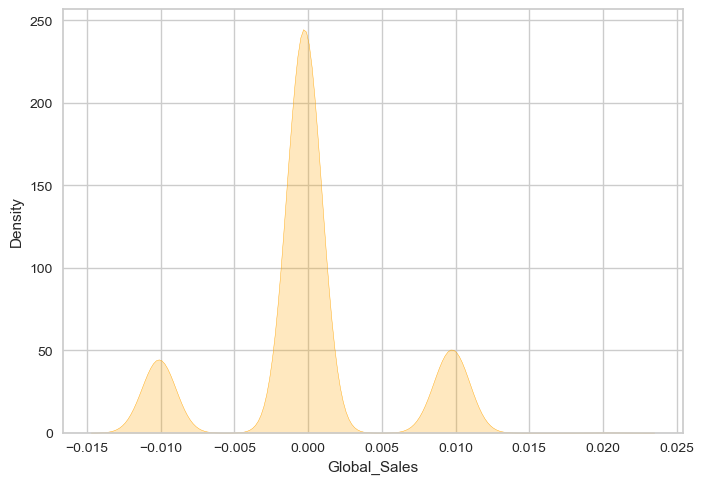

In [35]:
sns.kdeplot(x=residuals['Global_Sales'], fill=True, color='orange');

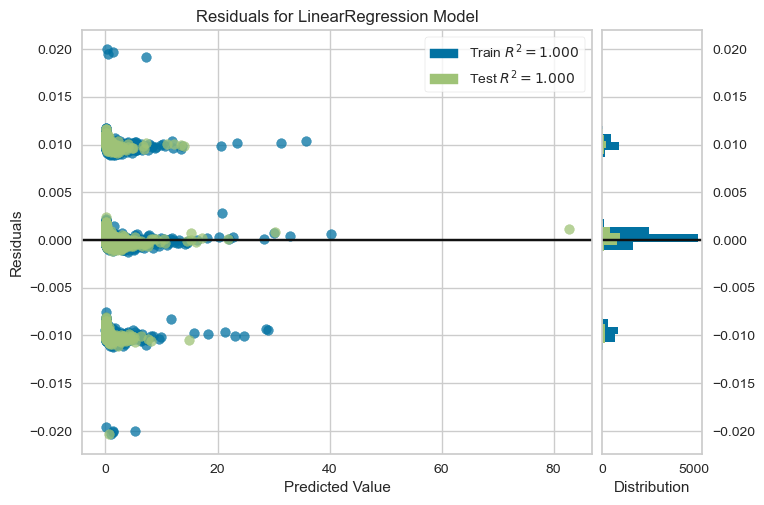

In [36]:
vis=ResidualsPlot(lr)
vis.fit(x_train,y_train)
vis.score(x_test,y_test)
vis.show()
plt.show()

&nbsp;&nbsp;&nbsp;Tahmin oranımız ilk eğitimden sonra r2_score'a bakarsak yeni çıkan bir video oyunu satış fiyatının tahminlerinde modelimiz neredeyse %99 doğruluk oranıyla tahmin edebiliyor oyun ücretlerini. Hata payımız yani RMSE: 0.00528 gibi bir değer geliyor. Modelimiz için peki, en ideal testin ne olduğunu öğrenmek adına diğer testleri de toplu yaparak modelimizi iyileştirip, bizim için en iyi test seçiminin ne olacağını öğrenelim.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [38]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Linear,0.999993,0.005287,0.003123
mlp_regressor,0.987534,0.221957,0.024022
Ridge,0.982724,0.261286,0.073055
Gradient Boosting,0.851764,0.765376,0.021138
Extra Tree,0.849540,0.771096,0.026458
Decision Tree,0.828560,0.823102,0.017434
KNeighborsRegressor,0.797943,0.893584,0.276852
XGBRegressor,0.788814,0.913546,0.038700
SGD,0.684508,1.116586,0.311151
AdaBoost,0.499157,1.406853,0.155918


&nbsp;&nbsp;&nbsp;En iyi sonuç veren test zaten 'LinearRegression' mış. 

&nbsp;&nbsp;&nbsp;Öyleyse modelimizi bir de **Derin Öğrenme** ile eğitip sonuçları karşılaştıralım. Fakat derin öğrenme öncesinde datamızı scale etmek ile başlıyoruz. 

In [39]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [40]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(x_train_scaled.shape[1],)))  
model.add(Dropout(0.2)) 
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.0001))

In [41]:
history = model.fit(x_train_scaled, y_train, epochs=200, batch_size=64, validation_data=(x_test_scaled, y_test), verbose=1)

Epoch 1/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.1507 - val_loss: 3.9199
Epoch 2/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.0237 - val_loss: 3.7850
Epoch 3/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.9035 - val_loss: 3.6420
Epoch 4/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.7926 - val_loss: 3.4931
Epoch 5/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.6803 - val_loss: 3.3429
Epoch 6/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5774 - val_loss: 3.2060
Epoch 7/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4914 - val_loss: 3.0845
Epoch 8/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4211 - val_loss: 2.9577
Epoch 9/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3504 - val_loss: 2.8358
Epoch 10/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2585 - val_loss: 2.7080
Epoch 11/200
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1783 - val_loss: 2.5739
Epoch 12/200
204/204 ━━━━━━━━━━━━━━━━━━━━

In [42]:
tahmin = model.predict(x_test_scaled)
r2 = r2_score(y_test, tahmin)

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step


In [43]:
r2

0.9876781105995178

In [44]:
mean_squared_error(y_test,tahmin)**.5

0.22066678954938088

In [45]:
model.save('video_games_model.h5')

&nbsp;&nbsp;&nbsp;Bu öğrenme sonuçlarına bakılırsa; r2_score'a göre 0.9895 olup yani modelimiz verilen detaylar ile yeni çıkacak olan bir video oyunun küreselde fiyatını %98 gibi bir oranla doğru tahmin edebilmektedir. Modelimizin Derin Öğrenme ile hata payı yani RMS ise 0.20304 gibi bir değerdir.

**Conclusion:**&nbsp;&nbsp; Sonuç olarak; Bu projede önce yapılan LinearRegression geleneksel makine öğrenme testi ve daha sonrasında yapılan Derin Öğrenme model testi oyun şirketleri tarafından üretilecek yeni oyunların küresel satışlarını rakamsal olarak tahmin edebilmesi açısından iyi vaatler veriyor. Modelimiz her iki öğrenme yönteminde de bir oyunun küreselde satışlarını %98 üstü bir oranla doğru tahmin edebilmektedir. <br>
&nbsp;&nbsp;&nbsp; İnsanların bu yıllarda boş zamanlarını doldurmak, sosyalleşmek ve bazen de öğrenmek ve eğlenmek için oynadıkları Video Oyunların hayatımızdaki yeri hiç azımsanmayacak boyutlarda iken, bu durumdan ekonomik açıdan gelir elde edebilmek adına kurulan şirketlerde yeni çıkartılacak oyunların hangisinin oyuncularca tutacak olacağını önceden tahmin edebilmek oyun şirketleri ve yatırımcılar açısından elmas gibi değerde bir bilgi oluyor ve bu ve benzeri modelleme çalışmaları mutlaka karşılığını bu zamanda da gelecekte de buluyor olacaktır.

Ve kapanış..